In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import rasterio
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

# Load data
with rasterio.open('../data/raw/S2_Season1_BOA_Composite.tif') as src:
    data = src.read().astype(np.float32)

data = np.nan_to_num(data, nan=0.0)
rgb = np.stack([data[2], data[1], data[0]], axis=-1)
rgb = np.clip(rgb / 0.3, 0, 1)
rgb_uint8 = (rgb * 255).astype(np.uint8)
print("Data loaded:", data.shape)

Data loaded: (10, 1146, 1001)


In [2]:
def add_haze(image, haze_level=0.4):
    haze = np.ones_like(image, dtype=np.float32) * 255 * haze_level
    hazed = image.astype(np.float32) * (1 - haze_level) + haze
    return np.clip(hazed, 0, 255).astype(np.uint8)

def get_dark_channel(image, patch_size=15):
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch_size, patch_size))
    return cv2.erode(min_channel, kernel)

def dcp_dehaze(image):
    dark = get_dark_channel(image)
    flat_dark = dark.flatten()
    indices = np.argsort(flat_dark)[-max(1, int(flat_dark.size * 0.001)):]
    rows, cols = np.unravel_index(indices, dark.shape)
    atmospheric = np.mean(image[rows, cols], axis=0)
    normalized = image.astype(np.float64) / atmospheric
    dark_norm = get_dark_channel(normalized, 15)
    transmission = np.clip(1 - 0.95 * dark_norm, 0.1, 1.0)
    recovered = np.zeros_like(image, dtype=np.float64)
    for c in range(3):
        recovered[:,:,c] = (image[:,:,c].astype(np.float64) - atmospheric[c]) / transmission + atmospheric[c]
    return np.clip(recovered, 0, 255).astype(np.uint8)

hazed = add_haze(rgb_uint8)
dehazed = dcp_dehaze(hazed)

print(f"Hazed  PSNR: {psnr(rgb_uint8, hazed):.2f} dB  SSIM: {ssim(rgb_uint8, hazed, channel_axis=2):.4f}")
print(f"Dehazed PSNR: {psnr(rgb_uint8, dehazed):.2f} dB  SSIM: {ssim(rgb_uint8, dehazed, channel_axis=2):.4f}")

Hazed  PSNR: 10.63 dB  SSIM: 0.6745
Dehazed PSNR: 21.29 dB  SSIM: 0.8532


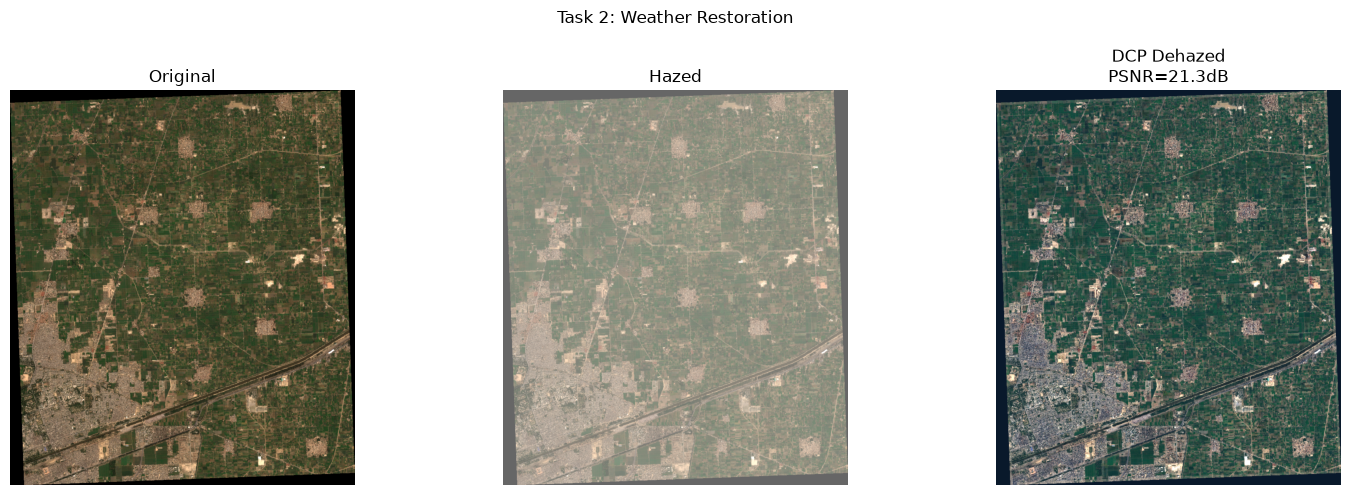

In [3]:
def apply_clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return np.stack([clahe.apply(image[:,:,c]) for c in range(3)], axis=-1)

clahe_img = apply_clahe(rgb_uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_uint8);   axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(hazed);       axes[1].set_title('Hazed');    axes[1].axis('off')
axes[2].imshow(dehazed);     axes[2].set_title(f'DCP Dehazed\nPSNR={psnr(rgb_uint8,dehazed):.1f}dB'); axes[2].axis('off')
plt.suptitle('Task 2: Weather Restoration')
plt.tight_layout()
plt.savefig('../data/outputs/task2_notebook_output.png', dpi=150)
plt.show()